In [1]:
!git clone https://github.com/VladWero08/time-series-ad-gan.git

Cloning into 'time-series-ad-gan'...
remote: Enumerating objects: 576, done.
remote: Counting objects: 100% (149/149), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 576 (delta 88), reused 109 (delta 51), pack-reused 427 (from 1)
Receiving objects: 100% (576/576), 16.49 MiB | 35.10 MiB/s, done.
Resolving deltas: 100% (346/346), done.


In [2]:
pip install pandas numpy kagglehub torch scipy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys 
import os

module_path = os.path.abspath("./time-series-ad-gan")
if module_path not in sys.path:
    sys.path.append(module_path)

In [4]:
import ast
import pandas as pd
import numpy as np
import json
import kagglehub
import typing as t
import torch
import matplotlib.pyplot as plt
from urllib.request import urlopen

from src.models.tad_gan import run_pipeline
from src.utils.preprocess import intervals_to_points
from src.utils.errors import point_wise_error, area_wise_error, dtw_error

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Working on {device}!")

Working on cuda!


In [6]:
def plot_signal(X: np.ndarray, y: np.ndarray) -> None:
    plt.figure(figsize=(15, 4))
    for idx in np.where(y == 1)[0]:
        plt.axvline(idx, color='red', alpha=0.4, linewidth=0.8, zorder=0)
    plt.plot(X, zorder=1)
    plt.show()

## **NASA**

In [8]:
NASA_SPLIT_REPO = "https://raw.githubusercontent.com/ML4ITS/mtad-gat-pytorch/refs/heads/main/datasets/data/"
NASA_LABELS_FILE = "labeled_anomalies.csv"
NASA_MSL_SPLIT = "msl_train_md.csv"
NASA_SMAP_SPLIT = "smap_train_md.csv"

In [9]:
NASA_HYPERPARAMS = {
    "device": device,
    "anomaly_type": "contextual",
    "verbose": False,
    "lr_gg": 1e-5,
    "lr_gf": 1e-5,
    "lr_dx": 1e-5,
    "lr_dz": 1e-5,
    "epochs": 1000,
    "rec_error_funcs": [("point", point_wise_error), ("area", area_wise_error)],
}

In [10]:
nasa_dataset_path = kagglehub.dataset_download("patrickfleith/nasa-anomaly-detection-dataset-smap-msl")
# path to the training samples from the Kaggle dataset
nasa_train_path = os.path.join(nasa_dataset_path, "data", "data", "train")
# path to the testing samples from the Kaggle dataset
nasa_test_path = os.path.join(nasa_dataset_path, "data", "data", "test")

In [11]:
# download the NASA labels that correspond to the labels for test data
nasa_labels_url = f"{NASA_SPLIT_REPO}{NASA_LABELS_FILE}"
nasa_labels = pd.read_csv(nasa_labels_url)

### **MSL**

In [16]:
MSL_HYPERPARAMS = NASA_HYPERPARAMS.copy()
MSL_HYPERPARAMS["verbose"] = True

In [13]:
msl_split_url = f"{NASA_SPLIT_REPO}{NASA_MSL_SPLIT}"
msl_split = pd.read_csv(msl_split_url)

# extract the channel names corresponding to the MSL dataset
msl_channel_names = list(msl_split["chan_id"].values) 
# add the .npy file extensions to the MSL file names
msl_file_names = [f"{msl_file_name}.npy" for msl_file_name in msl_channel_names]
# sort them alphabetically
msl_file_names.sort()

In [14]:
msl_train: list[np.ndarray] = []
msl_test: list[np.ndarray] = []
msl_test_y: list[list] = []

for msl_file_name in msl_file_names:
    # load both the train and test time series for the same channel, concatenate
    # the time series and add them to the MSL dataset
    msl_train_ts = np.load(os.path.join(nasa_train_path, msl_file_name))
    msl_test_ts = np.load(os.path.join(nasa_test_path, msl_file_name))

    # extract the anomaly labels for the test time-series
    # -4 is needed to get rid of the file extension from the name
    row = nasa_labels[nasa_labels["chan_id"] == msl_file_name[:-4]]
    msl_test_interval_str = row["anomaly_sequences"].iloc[0]
    msl_test_interval = ast.literal_eval(msl_test_interval_str)
    msl_test_labels = intervals_to_points(msl_test_interval, len(msl_test_ts))

    msl_train.append(msl_train_ts)
    msl_test.append(msl_test_ts)

    msl_test_y.append(msl_test_labels)

Channel C-1 Signal...
Epoch  25 | GG Loss: -0.035416 | GF Loss: 0.059093 | FC Loss: 0.600720 | DX Loss: 4.656388 | DZ Loss: 5.704910
Epoch  50 | GG Loss: 0.001569 | GF Loss: 0.061408 | FC Loss: 0.482907 | DX Loss: 2.465474 | DZ Loss: 3.363464
Epoch  75 | GG Loss: 0.071273 | GF Loss: 0.063274 | FC Loss: 0.337716 | DX Loss: 0.951499 | DZ Loss: 1.036604
Epoch 100 | GG Loss: 0.207443 | GF Loss: 0.058112 | FC Loss: 0.165701 | DX Loss: 0.231707 | DZ Loss: -0.475330
Epoch 125 | GG Loss: 0.478365 | GF Loss: 0.051736 | FC Loss: 0.061774 | DX Loss: 0.026943 | DZ Loss: -1.759243
Epoch 150 | GG Loss: 0.909339 | GF Loss: 0.041783 | FC Loss: 0.053476 | DX Loss: -0.011288 | DZ Loss: -3.661354
Epoch 175 | GG Loss: 1.489625 | GF Loss: 0.011945 | FC Loss: 0.053526 | DX Loss: -0.040390 | DZ Loss: -6.436067
Epoch 200 | GG Loss: 2.046354 | GF Loss: -0.089298 | FC Loss: 0.053980 | DX Loss: -0.131608 | DZ Loss: -9.838810
Epoch 225 | GG Loss: 2.229844 | GF Loss: -0.404525 | FC Loss: 0.054669 | DX Loss: -0.377

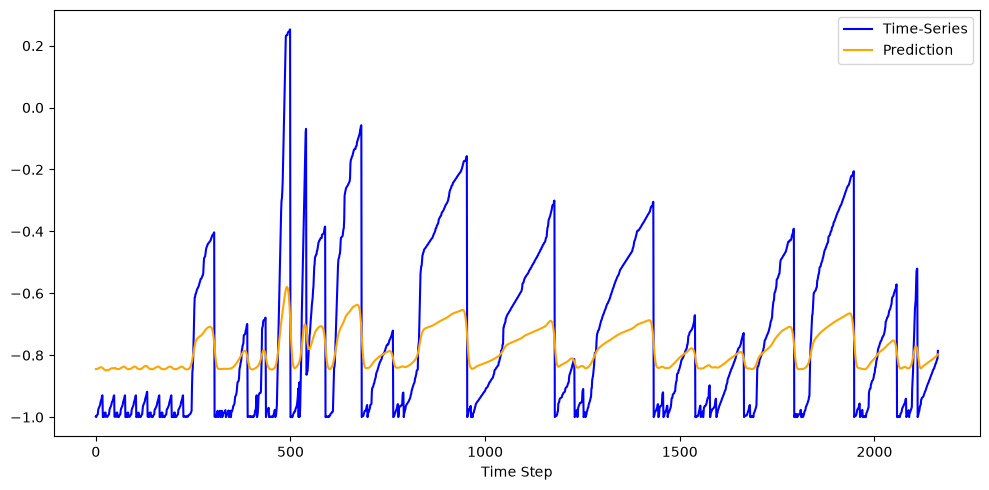

Channel C-2 Signal...
Epoch  25 | GG Loss: -0.086315 | GF Loss: -0.097875 | FC Loss: 0.775999 | DX Loss: 6.771399 | DZ Loss: 6.702479
Epoch  50 | GG Loss: -0.081594 | GF Loss: -0.132210 | FC Loss: 0.729820 | DX Loss: 5.595043 | DZ Loss: 5.965091
Epoch  75 | GG Loss: -0.074227 | GF Loss: -0.182414 | FC Loss: 0.682574 | DX Loss: 4.401284 | DZ Loss: 5.101669
Epoch 100 | GG Loss: -0.064970 | GF Loss: -0.252890 | FC Loss: 0.633050 | DX Loss: 3.229036 | DZ Loss: 4.169533
Epoch 125 | GG Loss: -0.055137 | GF Loss: -0.353488 | FC Loss: 0.579895 | DX Loss: 2.145083 | DZ Loss: 3.203827
Epoch 150 | GG Loss: -0.044198 | GF Loss: -0.498226 | FC Loss: 0.521618 | DX Loss: 1.116938 | DZ Loss: 2.272373
Epoch 175 | GG Loss: -0.031121 | GF Loss: -0.706117 | FC Loss: 0.456494 | DX Loss: 0.182873 | DZ Loss: 1.476081
Epoch 200 | GG Loss: -0.014084 | GF Loss: -0.995273 | FC Loss: 0.382636 | DX Loss: -0.640140 | DZ Loss: 0.815848
Epoch 225 | GG Loss: 0.009674 | GF Loss: -1.392138 | FC Loss: 0.298772 | DX Loss:

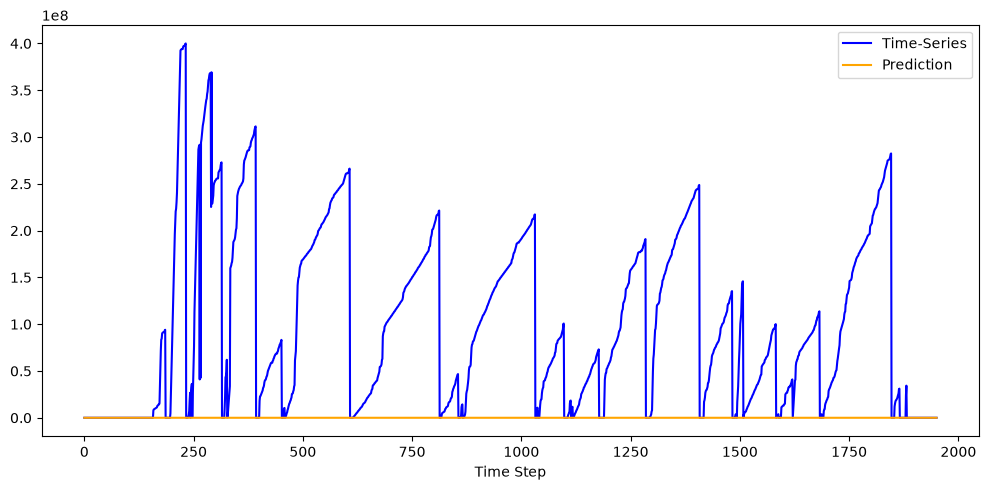

Channel D-14 Signal...
Epoch  25 | GG Loss: 0.091856 | GF Loss: -0.004190 | FC Loss: 0.726908 | DX Loss: 3.509499 | DZ Loss: 5.146844
Epoch  50 | GG Loss: 0.171563 | GF Loss: -0.528082 | FC Loss: 0.529273 | DX Loss: -0.468118 | DZ Loss: 1.802389
Epoch  75 | GG Loss: 0.330293 | GF Loss: -1.944791 | FC Loss: 0.209453 | DX Loss: -2.775050 | DZ Loss: -0.279575
Epoch 100 | GG Loss: 0.798811 | GF Loss: -4.444077 | FC Loss: 0.015184 | DX Loss: -2.066077 | DZ Loss: -1.683163
Epoch 125 | GG Loss: 1.616822 | GF Loss: -6.062987 | FC Loss: 0.041608 | DX Loss: -0.859377 | DZ Loss: -4.440139
Epoch 150 | GG Loss: 2.308362 | GF Loss: -6.860896 | FC Loss: 0.059932 | DX Loss: 0.261102 | DZ Loss: -8.459083
Epoch 175 | GG Loss: 2.146312 | GF Loss: -6.220421 | FC Loss: 0.058645 | DX Loss: 0.779210 | DZ Loss: -13.372601
Epoch 200 | GG Loss: 1.460316 | GF Loss: -4.381855 | FC Loss: 0.039196 | DX Loss: 0.539317 | DZ Loss: -19.401472
Epoch 225 | GG Loss: 0.446007 | GF Loss: -2.010525 | FC Loss: 0.018972 | DX L

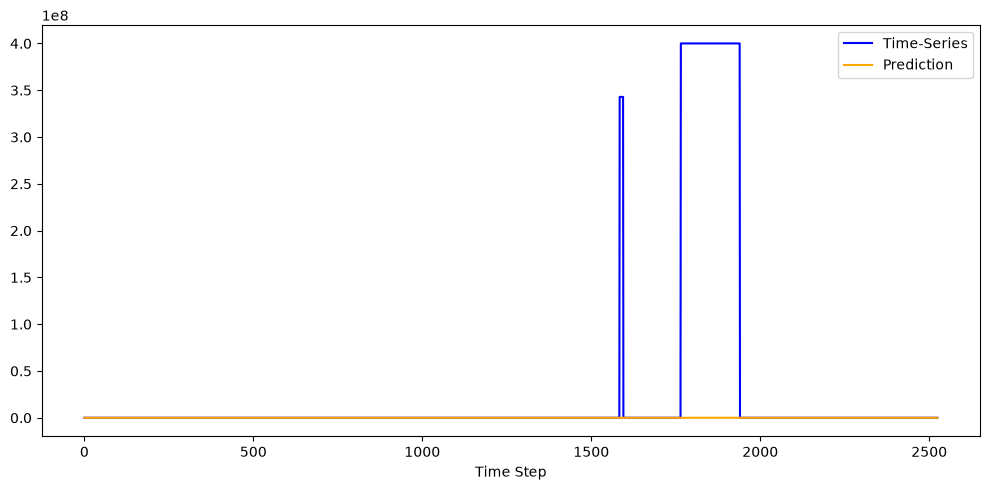

Channel D-15 Signal...
Epoch  25 | GG Loss: -0.003567 | GF Loss: 0.189837 | FC Loss: 0.684650 | DX Loss: 7.488433 | DZ Loss: 6.202736
Epoch  50 | GG Loss: 0.041107 | GF Loss: 0.226192 | FC Loss: 0.617288 | DX Loss: 5.330470 | DZ Loss: 4.210168
Epoch  75 | GG Loss: 0.112257 | GF Loss: 0.232238 | FC Loss: 0.543964 | DX Loss: 3.327392 | DZ Loss: 1.978032
Epoch 100 | GG Loss: 0.209893 | GF Loss: 0.169082 | FC Loss: 0.465308 | DX Loss: 1.706652 | DZ Loss: 0.278901
Epoch 125 | GG Loss: 0.340579 | GF Loss: -0.030665 | FC Loss: 0.392515 | DX Loss: 0.609043 | DZ Loss: -0.638681
Epoch 150 | GG Loss: 0.515618 | GF Loss: -0.365788 | FC Loss: 0.353200 | DX Loss: 0.030977 | DZ Loss: -1.332470
Epoch 175 | GG Loss: 0.719776 | GF Loss: -0.729678 | FC Loss: 0.350996 | DX Loss: -0.157453 | DZ Loss: -2.328049
Epoch 200 | GG Loss: 0.922370 | GF Loss: -1.049019 | FC Loss: 0.356076 | DX Loss: -0.117122 | DZ Loss: -3.744920
Epoch 225 | GG Loss: 1.063768 | GF Loss: -1.276398 | FC Loss: 0.359937 | DX Loss: 0.01

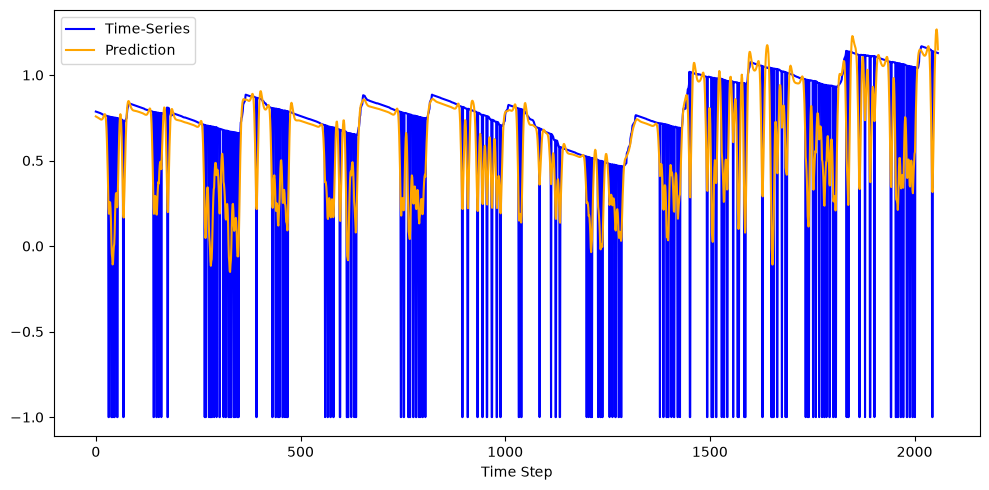

Channel D-16 Signal...
Epoch  25 | GG Loss: 0.055583 | GF Loss: -0.002964 | FC Loss: 0.876954 | DX Loss: 7.049818 | DZ Loss: 6.094924
Epoch  50 | GG Loss: 0.062508 | GF Loss: -0.007303 | FC Loss: 0.848787 | DX Loss: 5.733773 | DZ Loss: 4.674201
Epoch  75 | GG Loss: 0.069068 | GF Loss: -0.012467 | FC Loss: 0.820524 | DX Loss: 4.401831 | DZ Loss: 3.056301
Epoch 100 | GG Loss: 0.074829 | GF Loss: -0.019318 | FC Loss: 0.791759 | DX Loss: 3.166039 | DZ Loss: 1.539810
Epoch 125 | GG Loss: 0.081727 | GF Loss: -0.027697 | FC Loss: 0.762369 | DX Loss: 2.099657 | DZ Loss: 0.490645
Epoch 150 | GG Loss: 0.093147 | GF Loss: -0.038151 | FC Loss: 0.732404 | DX Loss: 1.264489 | DZ Loss: 0.053507
Epoch 175 | GG Loss: 0.114704 | GF Loss: -0.052665 | FC Loss: 0.702112 | DX Loss: 0.667748 | DZ Loss: -0.134636
Epoch 200 | GG Loss: 0.153530 | GF Loss: -0.071799 | FC Loss: 0.672033 | DX Loss: 0.290850 | DZ Loss: -0.282900
Epoch 225 | GG Loss: 0.218788 | GF Loss: -0.097364 | FC Loss: 0.643013 | DX Loss: 0.083

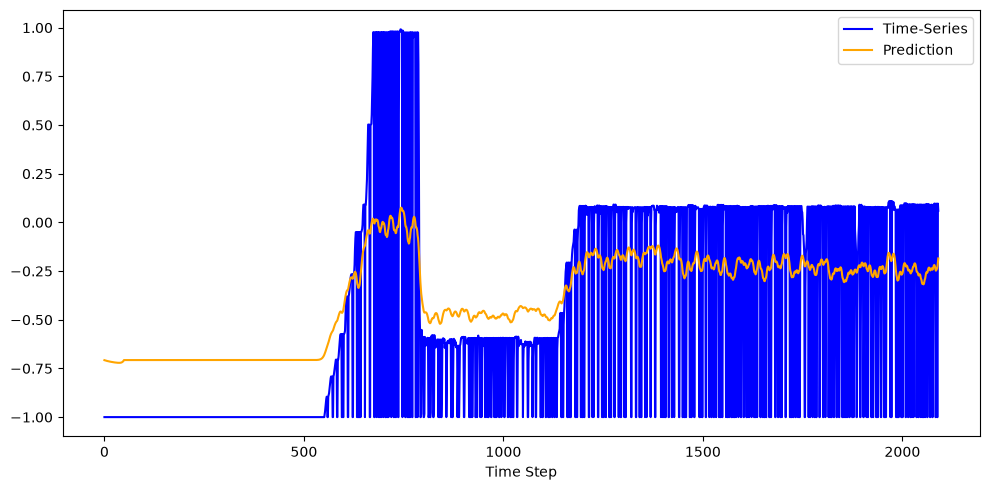

Channel F-4 Signal...
Epoch  25 | GG Loss: -0.049635 | GF Loss: -0.098892 | FC Loss: 0.630584 | DX Loss: 5.774249 | DZ Loss: 5.257701
Epoch  50 | GG Loss: -0.061543 | GF Loss: -0.167645 | FC Loss: 0.539686 | DX Loss: 3.148520 | DZ Loss: 3.026387
Epoch  75 | GG Loss: -0.079465 | GF Loss: -0.364855 | FC Loss: 0.435491 | DX Loss: 0.676860 | DZ Loss: 1.116874
Epoch 100 | GG Loss: -0.091094 | GF Loss: -0.806189 | FC Loss: 0.313991 | DX Loss: -1.084878 | DZ Loss: 0.035681
Epoch 125 | GG Loss: -0.051033 | GF Loss: -1.597130 | FC Loss: 0.201816 | DX Loss: -1.689637 | DZ Loss: -0.663609
Epoch 150 | GG Loss: 0.115641 | GF Loss: -2.615493 | FC Loss: 0.173670 | DX Loss: -1.240741 | DZ Loss: -1.895595
Epoch 175 | GG Loss: 0.382164 | GF Loss: -3.320798 | FC Loss: 0.192570 | DX Loss: -0.627478 | DZ Loss: -4.021280
Epoch 200 | GG Loss: 0.665800 | GF Loss: -3.741162 | FC Loss: 0.205987 | DX Loss: -0.142476 | DZ Loss: -6.980744
Epoch 225 | GG Loss: 0.798084 | GF Loss: -3.908189 | FC Loss: 0.214424 | DX 

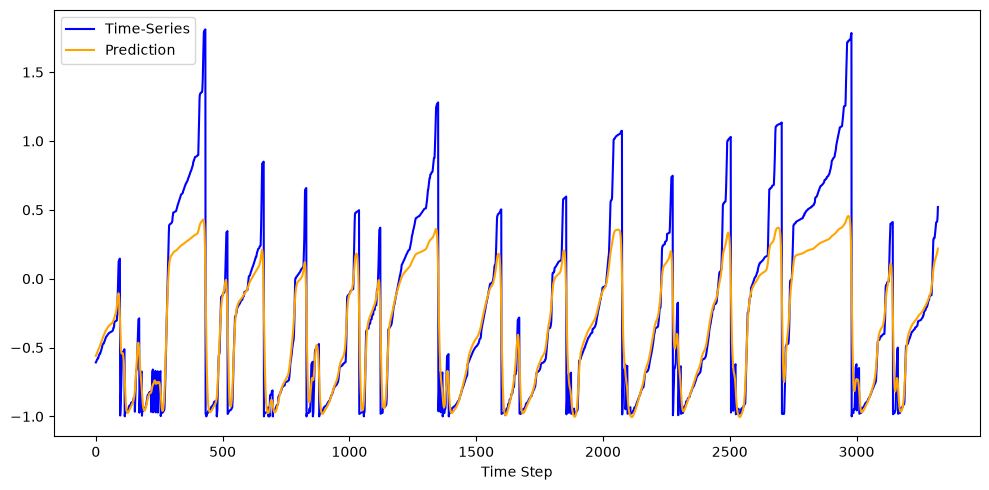

Channel F-5 Signal...
Epoch  25 | GG Loss: -0.109566 | GF Loss: 0.123021 | FC Loss: 0.575701 | DX Loss: 4.999318 | DZ Loss: 5.874346
Epoch  50 | GG Loss: -0.101461 | GF Loss: 0.135046 | FC Loss: 0.486497 | DX Loss: 2.716859 | DZ Loss: 3.436459
Epoch  75 | GG Loss: -0.087241 | GF Loss: 0.126606 | FC Loss: 0.380997 | DX Loss: 1.054298 | DZ Loss: 0.936757
Epoch 100 | GG Loss: -0.064610 | GF Loss: 0.088850 | FC Loss: 0.253020 | DX Loss: 0.248975 | DZ Loss: -0.899762
Epoch 125 | GG Loss: 0.016787 | GF Loss: 0.007441 | FC Loss: 0.137744 | DX Loss: 0.005510 | DZ Loss: -2.517312
Epoch 150 | GG Loss: 0.146973 | GF Loss: -0.130537 | FC Loss: 0.110571 | DX Loss: -0.078183 | DZ Loss: -4.539163
Epoch 175 | GG Loss: 0.295073 | GF Loss: -0.354912 | FC Loss: 0.109852 | DX Loss: -0.185566 | DZ Loss: -7.154254
Epoch 200 | GG Loss: 0.449006 | GF Loss: -0.761496 | FC Loss: 0.109969 | DX Loss: -0.361514 | DZ Loss: -10.621990
Epoch 225 | GG Loss: 0.604514 | GF Loss: -1.449102 | FC Loss: 0.111858 | DX Loss: 

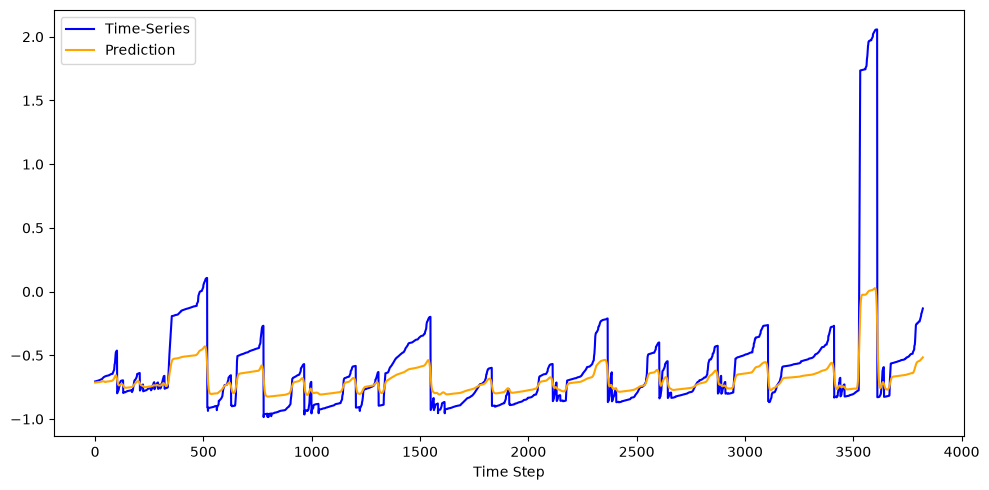

Channel F-7 Signal...
Epoch  25 | GG Loss: 0.123430 | GF Loss: 0.008065 | FC Loss: 0.598829 | DX Loss: 4.147035 | DZ Loss: 5.556676
Epoch  50 | GG Loss: 0.141962 | GF Loss: -0.023681 | FC Loss: 0.536549 | DX Loss: 2.006221 | DZ Loss: 2.974533
Epoch  75 | GG Loss: 0.163726 | GF Loss: -0.082212 | FC Loss: 0.471398 | DX Loss: 0.631895 | DZ Loss: 0.735856
Epoch 100 | GG Loss: 0.218351 | GF Loss: -0.182778 | FC Loss: 0.410970 | DX Loss: 0.022675 | DZ Loss: -0.097014
Epoch 125 | GG Loss: 0.367806 | GF Loss: -0.344010 | FC Loss: 0.382345 | DX Loss: -0.146417 | DZ Loss: -0.491319
Epoch 150 | GG Loss: 0.632146 | GF Loss: -0.566833 | FC Loss: 0.379492 | DX Loss: -0.213898 | DZ Loss: -1.374403
Epoch 175 | GG Loss: 0.989444 | GF Loss: -0.890888 | FC Loss: 0.379263 | DX Loss: -0.281884 | DZ Loss: -3.057209
Epoch 200 | GG Loss: 1.313606 | GF Loss: -1.343260 | FC Loss: 0.380628 | DX Loss: -0.315326 | DZ Loss: -5.553976
Epoch 225 | GG Loss: 1.393338 | GF Loss: -1.811757 | FC Loss: 0.384306 | DX Loss: 

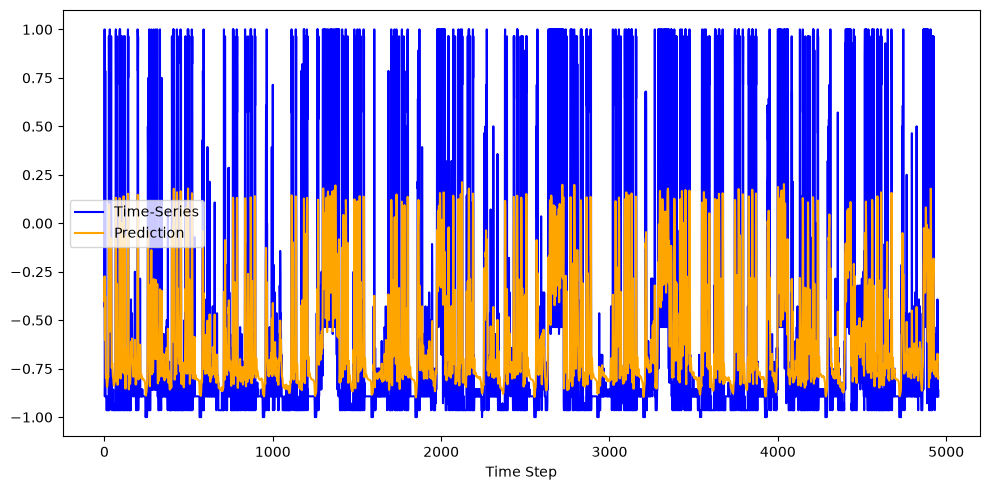

Channel F-8 Signal...
Epoch  25 | GG Loss: -0.109034 | GF Loss: 0.147352 | FC Loss: 0.777858 | DX Loss: 3.533401 | DZ Loss: 4.900926
Epoch  50 | GG Loss: -0.080934 | GF Loss: 0.161018 | FC Loss: 0.600043 | DX Loss: 0.340596 | DZ Loss: 1.683435
Epoch  75 | GG Loss: 0.315099 | GF Loss: -0.216015 | FC Loss: 0.337563 | DX Loss: -1.004898 | DZ Loss: -0.294581
Epoch 100 | GG Loss: 0.980163 | GF Loss: -1.291789 | FC Loss: 0.227660 | DX Loss: -1.093622 | DZ Loss: -1.378160
Epoch 125 | GG Loss: 1.245700 | GF Loss: -2.470918 | FC Loss: 0.243881 | DX Loss: -0.599442 | DZ Loss: -2.938491
Epoch 150 | GG Loss: 1.190389 | GF Loss: -3.236374 | FC Loss: 0.258699 | DX Loss: 0.229012 | DZ Loss: -5.710926
Epoch 175 | GG Loss: 1.009679 | GF Loss: -2.754161 | FC Loss: 0.251478 | DX Loss: 0.607755 | DZ Loss: -10.182188
Epoch 200 | GG Loss: 0.811888 | GF Loss: -1.550397 | FC Loss: 0.235638 | DX Loss: 0.437843 | DZ Loss: -16.510101
Epoch 225 | GG Loss: 0.494314 | GF Loss: -0.518021 | FC Loss: 0.226262 | DX Los

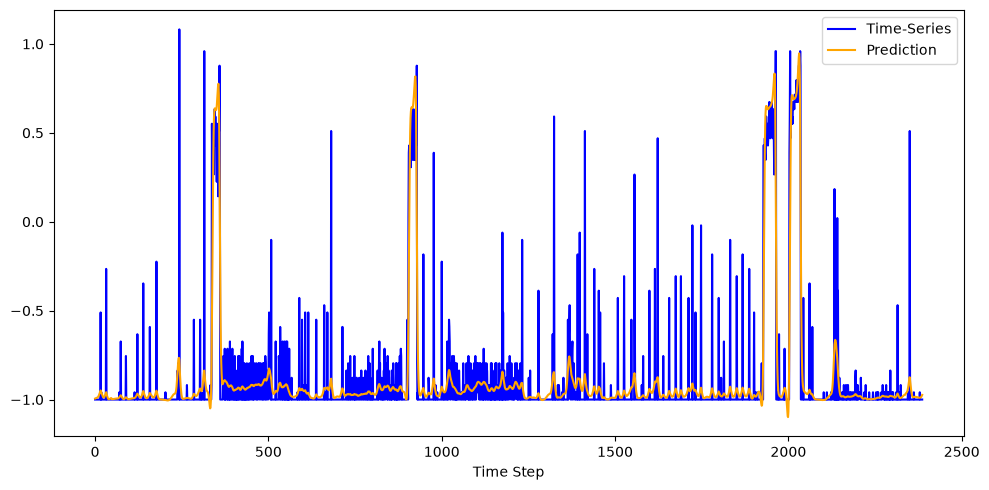

Channel M-1 Signal...
Epoch  25 | GG Loss: -0.291464 | GF Loss: -0.083013 | FC Loss: 0.191758 | DX Loss: 5.207705 | DZ Loss: 5.698261
Epoch  50 | GG Loss: -0.293238 | GF Loss: -0.101636 | FC Loss: 0.180051 | DX Loss: 2.967545 | DZ Loss: 3.092174
Epoch  75 | GG Loss: -0.289059 | GF Loss: -0.112235 | FC Loss: 0.172301 | DX Loss: 1.190140 | DZ Loss: -0.161468
Epoch 100 | GG Loss: -0.242102 | GF Loss: -0.120751 | FC Loss: 0.167713 | DX Loss: 0.246519 | DZ Loss: -3.713108
Epoch 125 | GG Loss: -0.119726 | GF Loss: -0.136881 | FC Loss: 0.165200 | DX Loss: -0.031345 | DZ Loss: -6.896665
Epoch 150 | GG Loss: -0.101157 | GF Loss: -0.168525 | FC Loss: 0.163742 | DX Loss: -0.074898 | DZ Loss: -9.844766
Epoch 175 | GG Loss: -0.184155 | GF Loss: -0.215989 | FC Loss: 0.162708 | DX Loss: -0.093142 | DZ Loss: -13.295428
Epoch 200 | GG Loss: -0.298397 | GF Loss: -0.280288 | FC Loss: 0.161791 | DX Loss: -0.111558 | DZ Loss: -17.756052
Epoch 225 | GG Loss: -0.506649 | GF Loss: -0.362797 | FC Loss: 0.16084

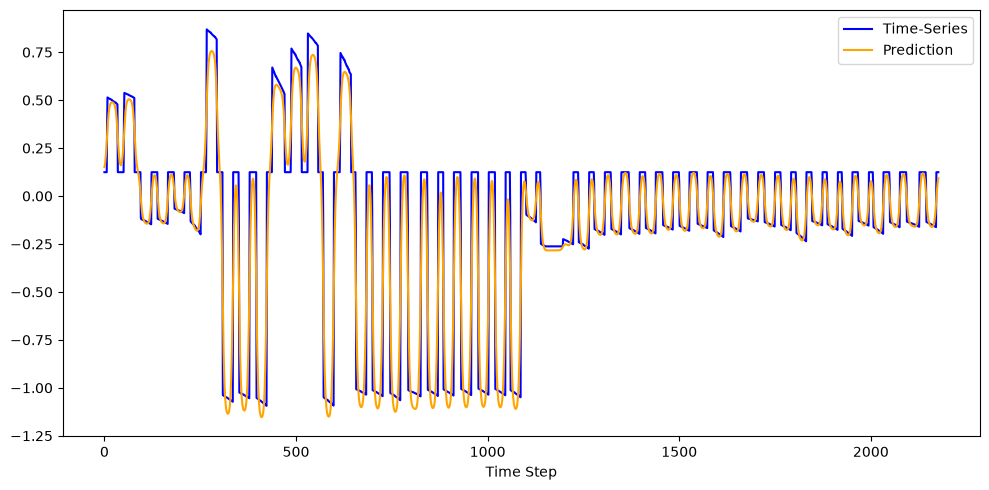

Channel M-2 Signal...
Epoch  25 | GG Loss: -0.051178 | GF Loss: -0.394118 | FC Loss: 0.461444 | DX Loss: 4.088090 | DZ Loss: 5.616100
Epoch  50 | GG Loss: -0.050489 | GF Loss: -0.790948 | FC Loss: 0.403904 | DX Loss: 0.911174 | DZ Loss: 2.932794
Epoch  75 | GG Loss: -0.035999 | GF Loss: -1.437306 | FC Loss: 0.341869 | DX Loss: -1.398490 | DZ Loss: 0.374668
Epoch 100 | GG Loss: 0.027783 | GF Loss: -2.304543 | FC Loss: 0.277586 | DX Loss: -2.106982 | DZ Loss: -1.334542
Epoch 125 | GG Loss: 0.153871 | GF Loss: -3.307029 | FC Loss: 0.226789 | DX Loss: -1.639465 | DZ Loss: -3.048922
Epoch 150 | GG Loss: 0.306216 | GF Loss: -4.193169 | FC Loss: 0.220444 | DX Loss: -0.758245 | DZ Loss: -5.445701
Epoch 175 | GG Loss: 0.429829 | GF Loss: -4.756082 | FC Loss: 0.244257 | DX Loss: -0.001607 | DZ Loss: -8.647247
Epoch 200 | GG Loss: 0.380314 | GF Loss: -4.969432 | FC Loss: 0.261905 | DX Loss: 0.516815 | DZ Loss: -12.367572
Epoch 225 | GG Loss: 0.162814 | GF Loss: -4.939903 | FC Loss: 0.269759 | DX 

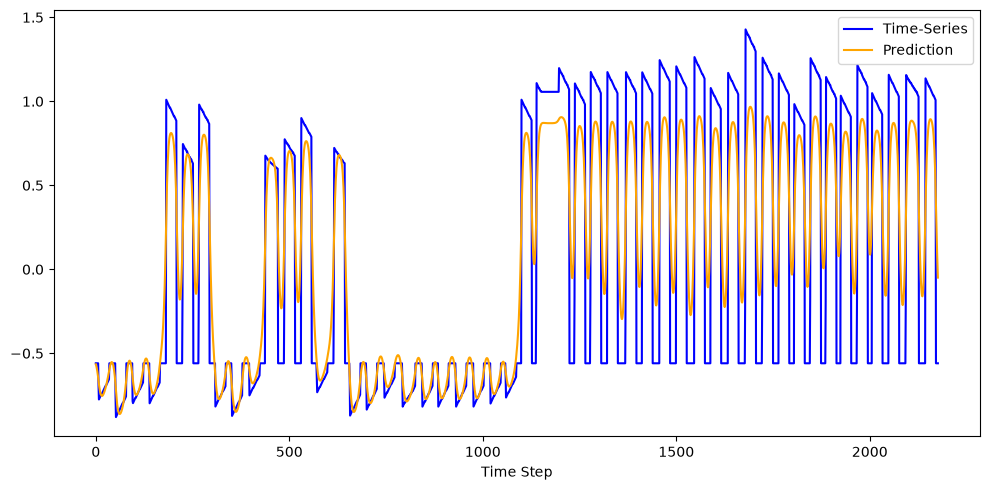

Channel M-3 Signal...
Epoch  25 | GG Loss: 0.087258 | GF Loss: -0.037096 | FC Loss: 0.760185 | DX Loss: 4.727658 | DZ Loss: 5.828657
Epoch  50 | GG Loss: 0.087318 | GF Loss: -0.067760 | FC Loss: 0.696298 | DX Loss: 2.803238 | DZ Loss: 4.060907
Epoch  75 | GG Loss: 0.088151 | GF Loss: -0.156178 | FC Loss: 0.623792 | DX Loss: 0.990157 | DZ Loss: 2.263273
Epoch 100 | GG Loss: 0.090493 | GF Loss: -0.358078 | FC Loss: 0.534833 | DX Loss: -0.524284 | DZ Loss: 0.897859
Epoch 125 | GG Loss: 0.096231 | GF Loss: -0.745968 | FC Loss: 0.427625 | DX Loss: -1.534474 | DZ Loss: 0.206390
Epoch 150 | GG Loss: 0.113297 | GF Loss: -1.383187 | FC Loss: 0.335347 | DX Loss: -1.862044 | DZ Loss: -0.027382
Epoch 175 | GG Loss: 0.165946 | GF Loss: -2.087658 | FC Loss: 0.316922 | DX Loss: -1.698440 | DZ Loss: -0.221301
Epoch 200 | GG Loss: 0.287178 | GF Loss: -2.629041 | FC Loss: 0.324757 | DX Loss: -1.470187 | DZ Loss: -0.691522
Epoch 225 | GG Loss: 0.509673 | GF Loss: -3.074477 | FC Loss: 0.331976 | DX Loss: 

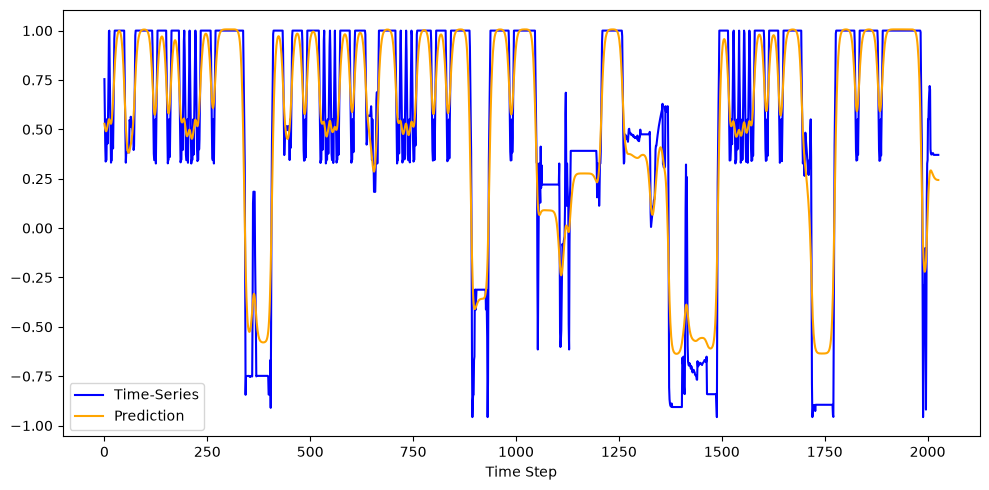

Channel M-4 Signal...
Epoch  25 | GG Loss: -0.135788 | GF Loss: 0.052686 | FC Loss: 0.614021 | DX Loss: 6.750402 | DZ Loss: 5.541504
Epoch  50 | GG Loss: -0.118497 | GF Loss: 0.032299 | FC Loss: 0.543683 | DX Loss: 5.091929 | DZ Loss: 3.610649
Epoch  75 | GG Loss: -0.083395 | GF Loss: 0.007013 | FC Loss: 0.466569 | DX Loss: 3.426839 | DZ Loss: 1.586609
Epoch 100 | GG Loss: -0.020007 | GF Loss: -0.023636 | FC Loss: 0.385278 | DX Loss: 1.944743 | DZ Loss: -0.060410
Epoch 125 | GG Loss: 0.106074 | GF Loss: -0.062998 | FC Loss: 0.314229 | DX Loss: 0.815237 | DZ Loss: -1.263060
Epoch 150 | GG Loss: 0.327577 | GF Loss: -0.112182 | FC Loss: 0.275736 | DX Loss: 0.149427 | DZ Loss: -2.606620
Epoch 175 | GG Loss: 0.616317 | GF Loss: -0.182494 | FC Loss: 0.264006 | DX Loss: -0.132554 | DZ Loss: -4.408930
Epoch 200 | GG Loss: 0.910554 | GF Loss: -0.298617 | FC Loss: 0.258296 | DX Loss: -0.267926 | DZ Loss: -6.595318
Epoch 225 | GG Loss: 1.093067 | GF Loss: -0.493909 | FC Loss: 0.253093 | DX Loss: 

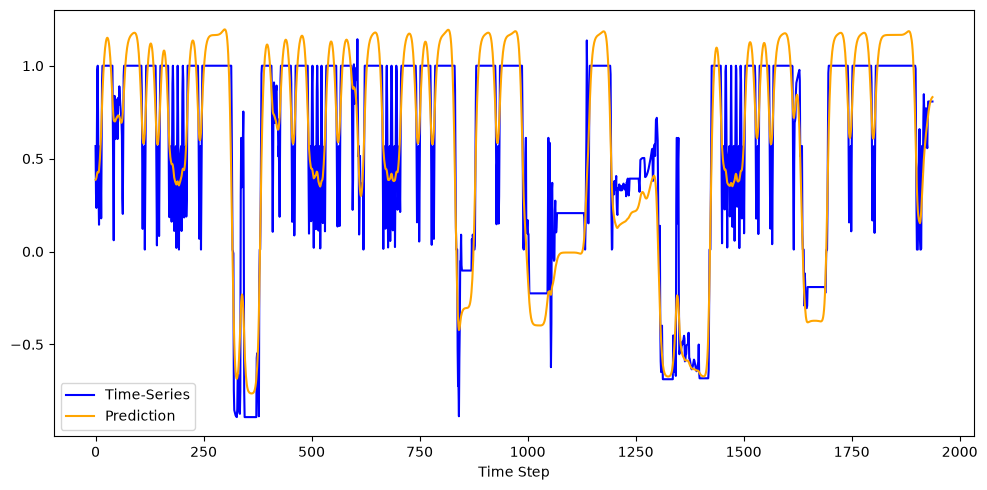

Channel M-5 Signal...
Epoch  25 | GG Loss: 0.025102 | GF Loss: 0.138649 | FC Loss: 0.476746 | DX Loss: 4.294880 | DZ Loss: 6.205682
Epoch  50 | GG Loss: 0.014735 | GF Loss: 0.139804 | FC Loss: 0.451989 | DX Loss: 2.724810 | DZ Loss: 4.311480
Epoch  75 | GG Loss: -0.010514 | GF Loss: 0.139341 | FC Loss: 0.429491 | DX Loss: 1.426097 | DZ Loss: 2.243208
Epoch 100 | GG Loss: -0.055654 | GF Loss: 0.137551 | FC Loss: 0.409468 | DX Loss: 0.551270 | DZ Loss: 0.682704
Epoch 125 | GG Loss: -0.112959 | GF Loss: 0.135778 | FC Loss: 0.392665 | DX Loss: 0.117000 | DZ Loss: 0.074529
Epoch 150 | GG Loss: -0.169834 | GF Loss: 0.135172 | FC Loss: 0.379792 | DX Loss: -0.025866 | DZ Loss: -0.059174
Epoch 175 | GG Loss: -0.235547 | GF Loss: 0.137422 | FC Loss: 0.370519 | DX Loss: -0.061297 | DZ Loss: -0.194367
Epoch 200 | GG Loss: -0.298409 | GF Loss: 0.143046 | FC Loss: 0.363331 | DX Loss: -0.082711 | DZ Loss: -0.647655
Epoch 225 | GG Loss: -0.279730 | GF Loss: 0.150144 | FC Loss: 0.356610 | DX Loss: -0.1

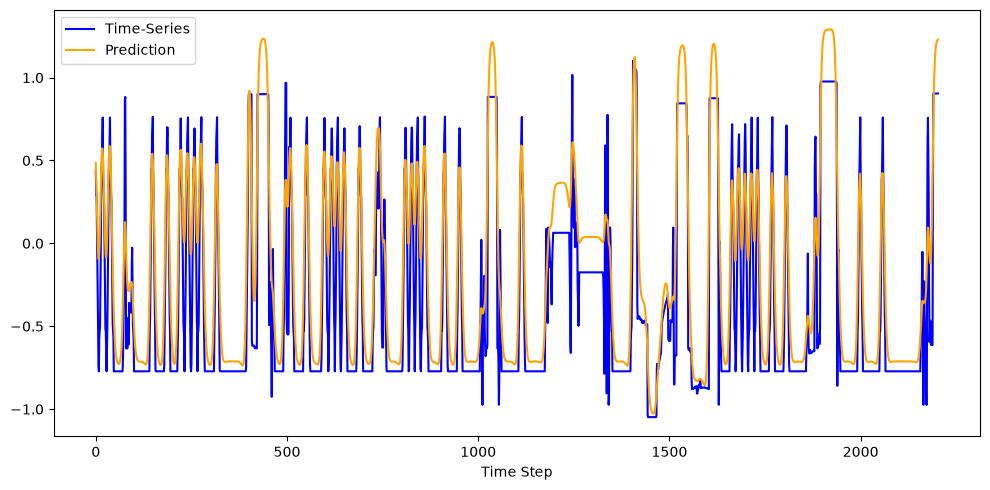

Channel M-6 Signal...
Epoch  25 | GG Loss: -0.037963 | GF Loss: 0.006199 | FC Loss: 0.809202 | DX Loss: 6.272065 | DZ Loss: 6.642450
Epoch  50 | GG Loss: -0.037552 | GF Loss: 0.013427 | FC Loss: 0.745624 | DX Loss: 4.664885 | DZ Loss: 5.423273
Epoch  75 | GG Loss: -0.034877 | GF Loss: 0.017620 | FC Loss: 0.676386 | DX Loss: 3.053023 | DZ Loss: 4.062281
Epoch 100 | GG Loss: -0.025313 | GF Loss: 0.010442 | FC Loss: 0.597179 | DX Loss: 1.663780 | DZ Loss: 2.694987
Epoch 125 | GG Loss: -0.001940 | GF Loss: -0.020635 | FC Loss: 0.502003 | DX Loss: 0.603794 | DZ Loss: 1.501744
Epoch 150 | GG Loss: 0.046395 | GF Loss: -0.097777 | FC Loss: 0.383151 | DX Loss: -0.137209 | DZ Loss: 0.548965
Epoch 175 | GG Loss: 0.139764 | GF Loss: -0.271626 | FC Loss: 0.236268 | DX Loss: -0.639121 | DZ Loss: -0.116210
Epoch 200 | GG Loss: 0.309031 | GF Loss: -0.601843 | FC Loss: 0.086360 | DX Loss: -0.939895 | DZ Loss: -0.679952
Epoch 225 | GG Loss: 0.542511 | GF Loss: -1.102889 | FC Loss: 0.016907 | DX Loss: -1

/time-series-ad-gan/src/utils/errors.py:199: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Z_dx = zscore(np.array(agg_dx))
/time-series-ad-gan/src/utils/errors.py:199: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Z_dx = zscore(np.array(agg_dx))



Metrics point
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000

Metrics area
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


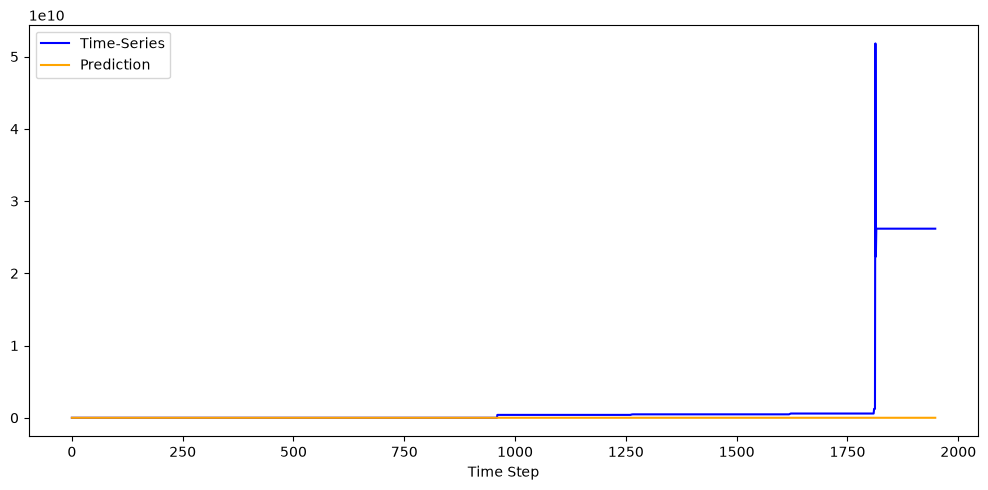

Channel M-7 Signal...
Epoch  25 | GG Loss: 0.005648 | GF Loss: 0.037146 | FC Loss: 0.828138 | DX Loss: 6.608872 | DZ Loss: 6.368675
Epoch  50 | GG Loss: 0.000656 | GF Loss: -0.007908 | FC Loss: 0.763220 | DX Loss: 4.509300 | DZ Loss: 5.096080
Epoch  75 | GG Loss: -0.004550 | GF Loss: -0.136518 | FC Loss: 0.690462 | DX Loss: 2.109200 | DZ Loss: 3.658930
Epoch 100 | GG Loss: -0.009590 | GF Loss: -0.396820 | FC Loss: 0.604463 | DX Loss: -0.166507 | DZ Loss: 2.259959
Epoch 125 | GG Loss: -0.013193 | GF Loss: -0.834609 | FC Loss: 0.498016 | DX Loss: -2.018878 | DZ Loss: 1.098346
Epoch 150 | GG Loss: -0.011689 | GF Loss: -1.511932 | FC Loss: 0.362751 | DX Loss: -3.221375 | DZ Loss: 0.297498
Epoch 175 | GG Loss: 0.002850 | GF Loss: -2.500966 | FC Loss: 0.200209 | DX Loss: -3.619758 | DZ Loss: -0.192002
Epoch 200 | GG Loss: 0.046509 | GF Loss: -3.781450 | FC Loss: 0.065186 | DX Loss: -3.190163 | DZ Loss: -0.576867
Epoch 225 | GG Loss: 0.120887 | GF Loss: -5.058657 | FC Loss: 0.043985 | DX Loss

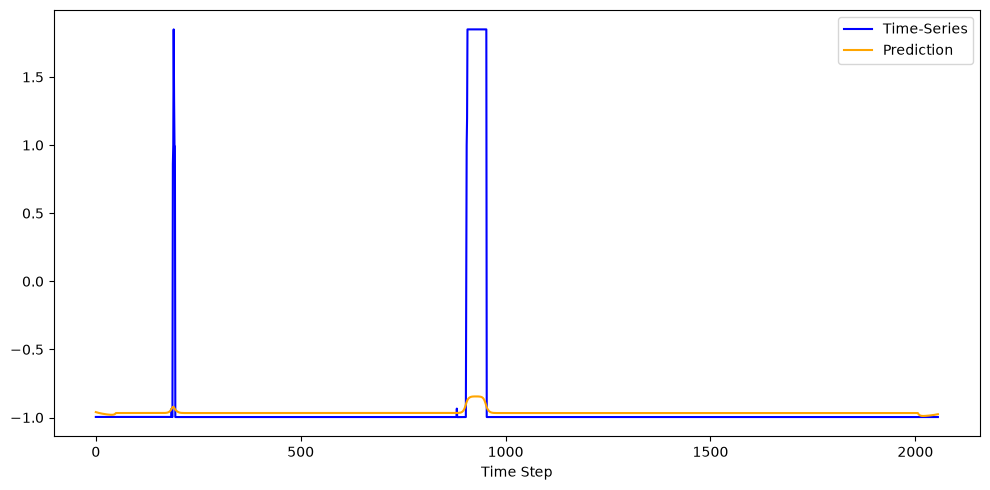

Channel P-10 Signal...
Epoch  25 | GG Loss: 0.044679 | GF Loss: 0.005691 | FC Loss: 0.026579 | DX Loss: 2.887734 | DZ Loss: 3.705339
Epoch  50 | GG Loss: 0.038206 | GF Loss: 0.009095 | FC Loss: 0.026561 | DX Loss: 0.202869 | DZ Loss: 0.324034
Epoch  75 | GG Loss: 0.026769 | GF Loss: 0.002870 | FC Loss: 0.026531 | DX Loss: 0.003627 | DZ Loss: -0.499045
Epoch 100 | GG Loss: 0.063840 | GF Loss: -0.015352 | FC Loss: 0.026497 | DX Loss: 0.000514 | DZ Loss: -2.742607
Epoch 125 | GG Loss: 0.037526 | GF Loss: -0.044044 | FC Loss: 0.026486 | DX Loss: -0.002704 | DZ Loss: -7.852078
Epoch 150 | GG Loss: -0.396183 | GF Loss: -0.071393 | FC Loss: 0.026529 | DX Loss: -0.002036 | DZ Loss: -15.098831
Epoch 175 | GG Loss: -1.475891 | GF Loss: -0.080790 | FC Loss: 0.026532 | DX Loss: 0.000046 | DZ Loss: -23.909302
Epoch 200 | GG Loss: -2.780098 | GF Loss: -0.070537 | FC Loss: 0.026412 | DX Loss: -0.000233 | DZ Loss: -34.906789
Epoch 225 | GG Loss: -3.475450 | GF Loss: -0.065813 | FC Loss: 0.026274 | DX 

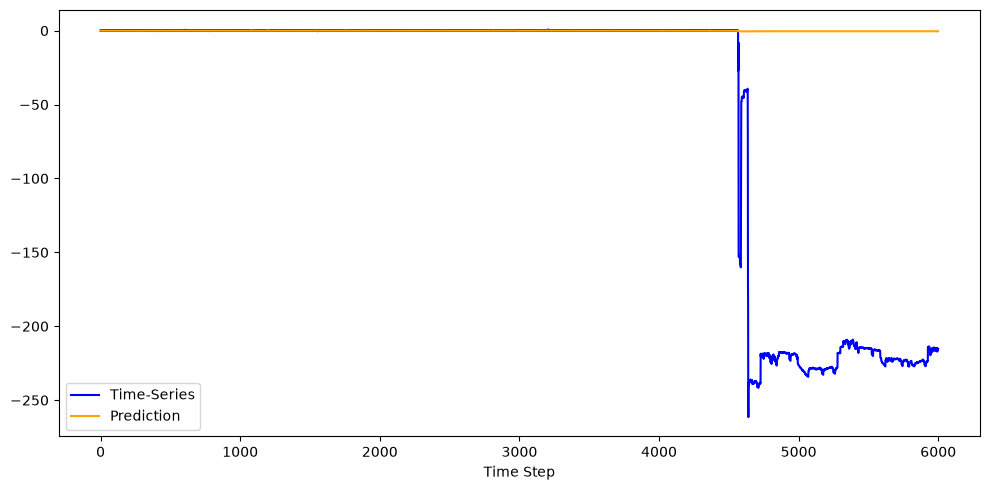

Channel P-11 Signal...
Epoch  25 | GG Loss: 0.022310 | GF Loss: -0.087493 | FC Loss: 0.311454 | DX Loss: 4.042642 | DZ Loss: 3.915275
Epoch  50 | GG Loss: 0.037382 | GF Loss: -0.107687 | FC Loss: 0.198796 | DX Loss: 0.822237 | DZ Loss: 0.766884
Epoch  75 | GG Loss: 0.046257 | GF Loss: -0.166403 | FC Loss: 0.110252 | DX Loss: -0.035903 | DZ Loss: 0.023698
Epoch 100 | GG Loss: 0.138375 | GF Loss: -0.271533 | FC Loss: 0.099549 | DX Loss: -0.121942 | DZ Loss: -0.053083
Epoch 125 | GG Loss: 0.649376 | GF Loss: -0.511575 | FC Loss: 0.097914 | DX Loss: -0.209853 | DZ Loss: -0.932021
Epoch 150 | GG Loss: 1.328761 | GF Loss: -1.040777 | FC Loss: 0.100037 | DX Loss: -0.171861 | DZ Loss: -3.903344
Epoch 175 | GG Loss: 1.398108 | GF Loss: -1.253936 | FC Loss: 0.101913 | DX Loss: 0.103012 | DZ Loss: -8.505225
Epoch 200 | GG Loss: 0.543430 | GF Loss: -0.619450 | FC Loss: 0.090930 | DX Loss: 0.086437 | DZ Loss: -14.449786
Epoch 225 | GG Loss: -1.063986 | GF Loss: -0.212573 | FC Loss: 0.079944 | DX Lo

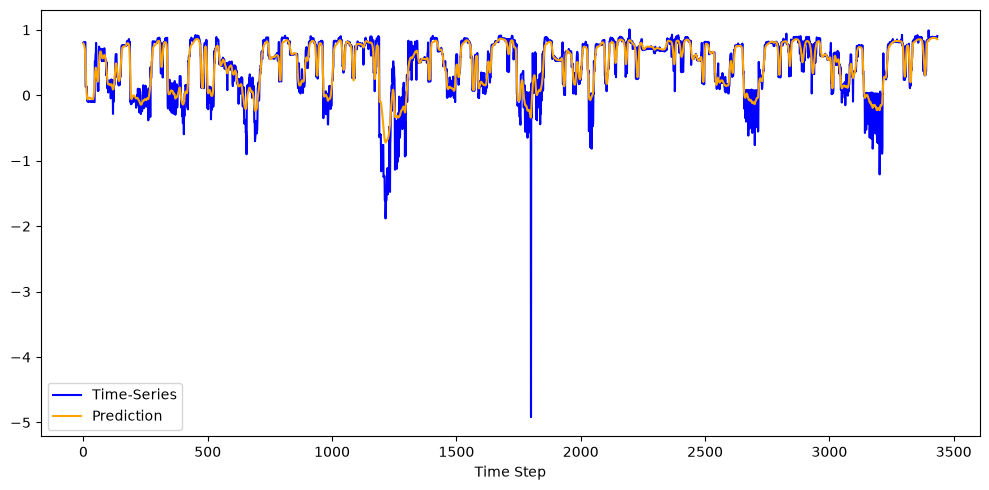

Channel P-14 Signal...
Epoch  25 | GG Loss: 0.075789 | GF Loss: 0.078996 | FC Loss: 0.030462 | DX Loss: 3.903627 | DZ Loss: 4.795485
Epoch  50 | GG Loss: 0.074142 | GF Loss: 0.077972 | FC Loss: 0.027267 | DX Loss: 0.954804 | DZ Loss: 2.246210
Epoch  75 | GG Loss: 0.058991 | GF Loss: 0.078773 | FC Loss: 0.027041 | DX Loss: 0.075885 | DZ Loss: 0.565371
Epoch 100 | GG Loss: 0.035771 | GF Loss: 0.080186 | FC Loss: 0.027025 | DX Loss: 0.002440 | DZ Loss: 0.060092
Epoch 125 | GG Loss: 0.018050 | GF Loss: 0.083211 | FC Loss: 0.027011 | DX Loss: 0.000699 | DZ Loss: -0.045597
Epoch 150 | GG Loss: -0.009378 | GF Loss: 0.088320 | FC Loss: 0.026998 | DX Loss: -0.000059 | DZ Loss: -0.479291
Epoch 175 | GG Loss: 0.036203 | GF Loss: 0.097893 | FC Loss: 0.026984 | DX Loss: -0.002180 | DZ Loss: -2.164525
Epoch 200 | GG Loss: 0.323365 | GF Loss: 0.113951 | FC Loss: 0.026970 | DX Loss: -0.004983 | DZ Loss: -5.582256
Epoch 225 | GG Loss: 0.793401 | GF Loss: 0.141653 | FC Loss: 0.026961 | DX Loss: -0.00910

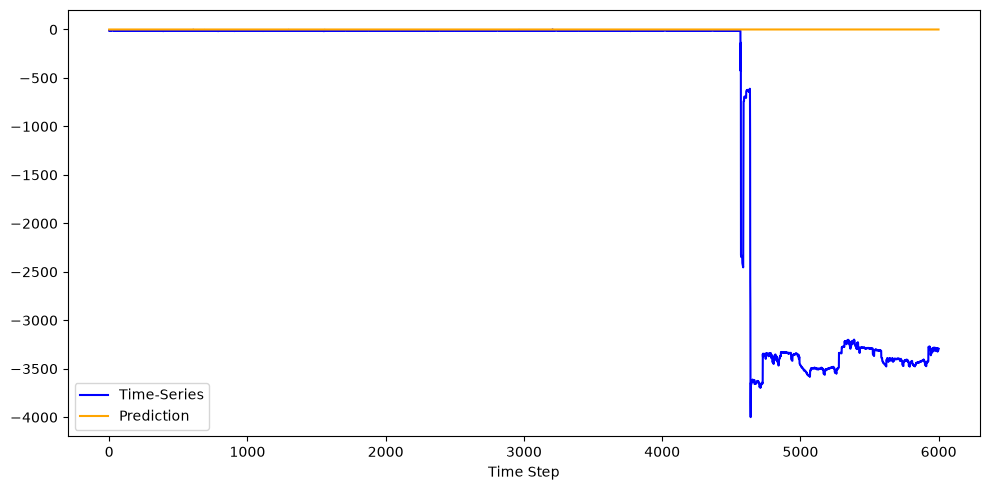

Channel P-15 Signal...
Epoch  25 | GG Loss: -0.026024 | GF Loss: 0.069339 | FC Loss: 0.316990 | DX Loss: 4.505044 | DZ Loss: 5.097984
Epoch  50 | GG Loss: 0.059295 | GF Loss: 0.058534 | FC Loss: 0.215085 | DX Loss: 1.741700 | DZ Loss: 1.812631
Epoch  75 | GG Loss: 0.204232 | GF Loss: 0.023209 | FC Loss: 0.109759 | DX Loss: 0.336916 | DZ Loss: -0.224820
Epoch 100 | GG Loss: 0.497588 | GF Loss: -0.031117 | FC Loss: 0.067855 | DX Loss: 0.013353 | DZ Loss: -1.488961
Epoch 125 | GG Loss: 0.805847 | GF Loss: -0.105454 | FC Loss: 0.065934 | DX Loss: -0.041016 | DZ Loss: -3.849222
Epoch 150 | GG Loss: 0.756062 | GF Loss: -0.247343 | FC Loss: 0.066110 | DX Loss: -0.089257 | DZ Loss: -7.373717
Epoch 175 | GG Loss: 0.113663 | GF Loss: -0.507942 | FC Loss: 0.067070 | DX Loss: -0.099335 | DZ Loss: -11.777155
Epoch 200 | GG Loss: -0.677440 | GF Loss: -0.758826 | FC Loss: 0.069859 | DX Loss: 0.028786 | DZ Loss: -17.542199
Epoch 225 | GG Loss: -1.310297 | GF Loss: -0.675403 | FC Loss: 0.071461 | DX Lo

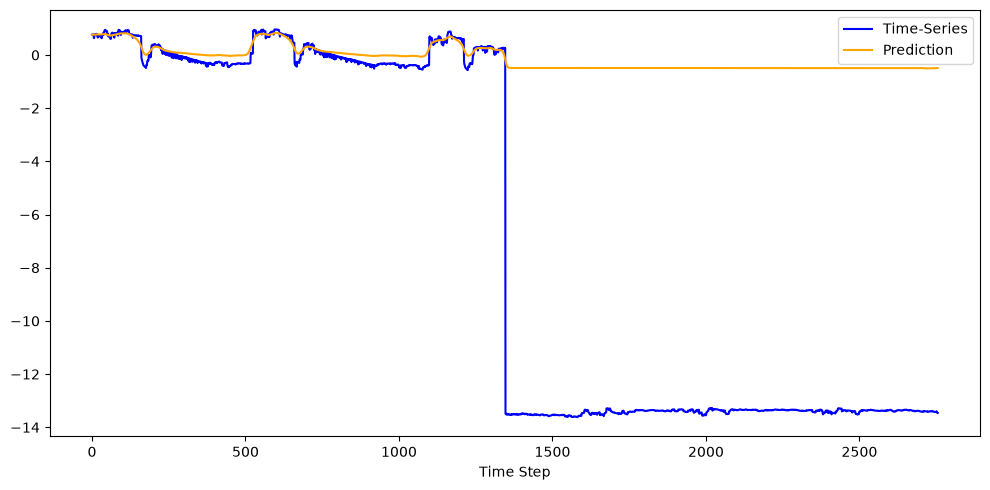

Channel S-2 Signal...
Epoch  25 | GG Loss: -0.063083 | GF Loss: 0.021117 | FC Loss: 1.031023 | DX Loss: 6.113448 | DZ Loss: 6.737437
Epoch  50 | GG Loss: -0.062607 | GF Loss: 0.013299 | FC Loss: 0.971199 | DX Loss: 5.310700 | DZ Loss: 5.954399
Epoch  75 | GG Loss: -0.061586 | GF Loss: 0.005403 | FC Loss: 0.908708 | DX Loss: 4.473577 | DZ Loss: 5.069259
Epoch 100 | GG Loss: -0.060260 | GF Loss: -0.003065 | FC Loss: 0.841725 | DX Loss: 3.666632 | DZ Loss: 4.126412
Epoch 125 | GG Loss: -0.058452 | GF Loss: -0.012587 | FC Loss: 0.768304 | DX Loss: 2.878592 | DZ Loss: 3.186482
Epoch 150 | GG Loss: -0.056394 | GF Loss: -0.024231 | FC Loss: 0.686366 | DX Loss: 2.141366 | DZ Loss: 2.285796
Epoch 175 | GG Loss: -0.053430 | GF Loss: -0.039920 | FC Loss: 0.593689 | DX Loss: 1.468993 | DZ Loss: 1.511281
Epoch 200 | GG Loss: -0.049026 | GF Loss: -0.066230 | FC Loss: 0.488149 | DX Loss: 0.876772 | DZ Loss: 0.879004
Epoch 225 | GG Loss: -0.042031 | GF Loss: -0.109696 | FC Loss: 0.369493 | DX Loss: 0.

/time-series-ad-gan/src/utils/errors.py:199: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Z_dx = zscore(np.array(agg_dx))
/time-series-ad-gan/src/utils/errors.py:199: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Z_dx = zscore(np.array(agg_dx))



Metrics point
-------
Precision = 0.2500
Recall = 1.0000
F1 = 0.4000

Metrics area
-------
Precision = 0.2500
Recall = 1.0000
F1 = 0.4000


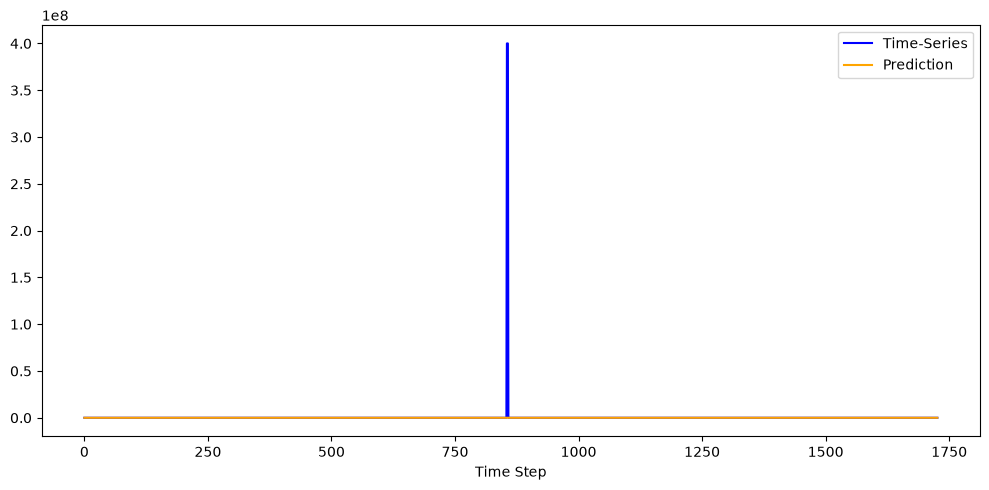

Channel T-12 Signal...
Epoch  25 | GG Loss: 0.015797 | GF Loss: 0.011166 | FC Loss: 0.203696 | DX Loss: 6.892539 | DZ Loss: 6.431886
Epoch  50 | GG Loss: 0.018120 | GF Loss: 0.023154 | FC Loss: 0.203079 | DX Loss: 5.386415 | DZ Loss: 5.142131
Epoch  75 | GG Loss: 0.020072 | GF Loss: 0.036467 | FC Loss: 0.202452 | DX Loss: 3.927943 | DZ Loss: 3.703669
Epoch 100 | GG Loss: 0.021774 | GF Loss: 0.046807 | FC Loss: 0.201775 | DX Loss: 2.632572 | DZ Loss: 2.330370
Epoch 125 | GG Loss: 0.023680 | GF Loss: 0.056028 | FC Loss: 0.201018 | DX Loss: 1.598824 | DZ Loss: 1.238629
Epoch 150 | GG Loss: 0.026860 | GF Loss: 0.059142 | FC Loss: 0.200142 | DX Loss: 0.867461 | DZ Loss: 0.503811
Epoch 175 | GG Loss: 0.032276 | GF Loss: 0.056759 | FC Loss: 0.199098 | DX Loss: 0.440765 | DZ Loss: 0.145492
Epoch 200 | GG Loss: 0.041677 | GF Loss: 0.047420 | FC Loss: 0.197807 | DX Loss: 0.233277 | DZ Loss: 0.037678
Epoch 225 | GG Loss: 0.058101 | GF Loss: 0.033922 | FC Loss: 0.196201 | DX Loss: 0.156155 | DZ Lo

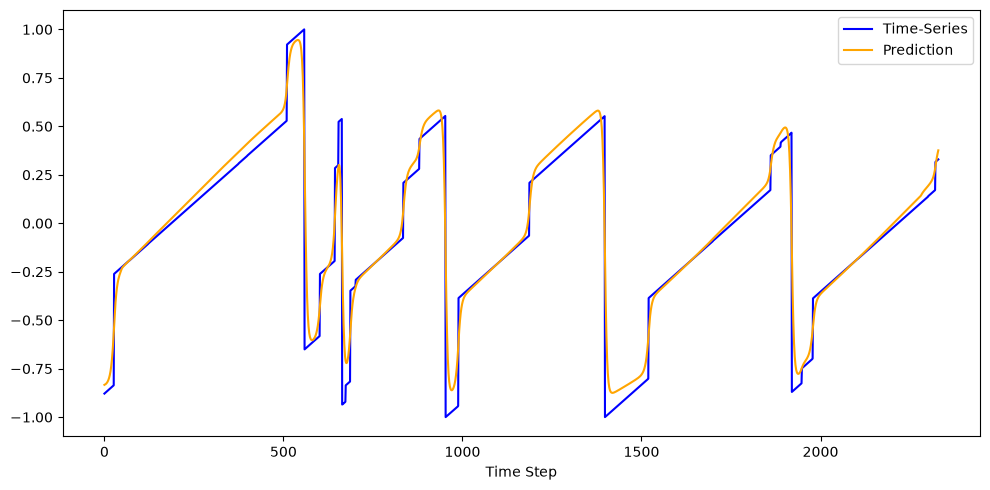

Channel T-13 Signal...
Epoch  25 | GG Loss: -0.024271 | GF Loss: 0.085308 | FC Loss: 0.335595 | DX Loss: 6.781846 | DZ Loss: 6.329735
Epoch  50 | GG Loss: -0.014661 | GF Loss: 0.087323 | FC Loss: 0.323622 | DX Loss: 5.569286 | DZ Loss: 5.088682
Epoch  75 | GG Loss: -0.001784 | GF Loss: 0.089146 | FC Loss: 0.312610 | DX Loss: 4.356257 | DZ Loss: 3.720879
Epoch 100 | GG Loss: 0.014709 | GF Loss: 0.090597 | FC Loss: 0.302413 | DX Loss: 3.212002 | DZ Loss: 2.347214
Epoch 125 | GG Loss: 0.034164 | GF Loss: 0.091307 | FC Loss: 0.292968 | DX Loss: 2.204381 | DZ Loss: 1.123988
Epoch 150 | GG Loss: 0.061173 | GF Loss: 0.091468 | FC Loss: 0.284265 | DX Loss: 1.378897 | DZ Loss: 0.172470
Epoch 175 | GG Loss: 0.101586 | GF Loss: 0.090992 | FC Loss: 0.276276 | DX Loss: 0.764420 | DZ Loss: -0.557067
Epoch 200 | GG Loss: 0.164094 | GF Loss: 0.090350 | FC Loss: 0.268984 | DX Loss: 0.366031 | DZ Loss: -1.291789
Epoch 225 | GG Loss: 0.246537 | GF Loss: 0.087169 | FC Loss: 0.262401 | DX Loss: 0.140730 | 

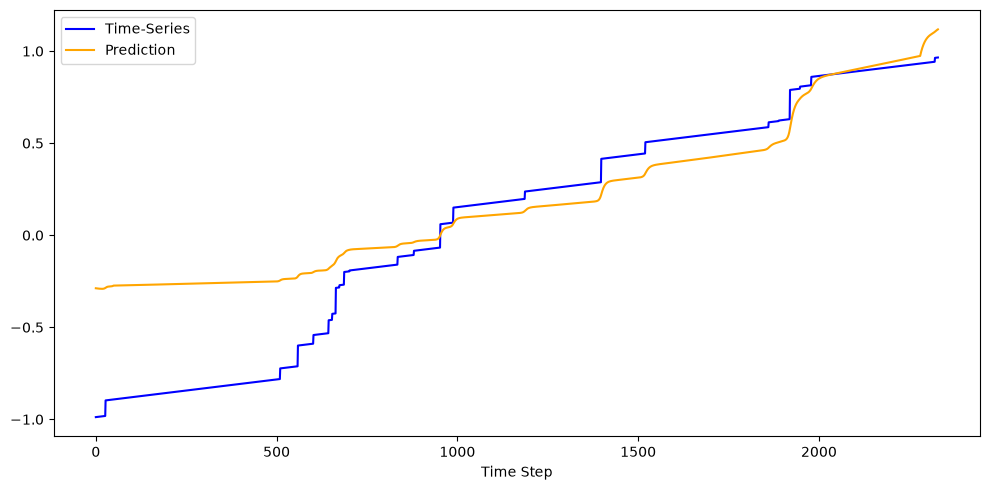

Channel T-4 Signal...
Epoch  25 | GG Loss: -0.020112 | GF Loss: -0.121879 | FC Loss: 0.994787 | DX Loss: 5.420148 | DZ Loss: 5.836045
Epoch  50 | GG Loss: -0.018196 | GF Loss: -0.128611 | FC Loss: 0.983655 | DX Loss: 3.214191 | DZ Loss: 3.515413
Epoch  75 | GG Loss: -0.013945 | GF Loss: -0.135884 | FC Loss: 0.968452 | DX Loss: 1.392478 | DZ Loss: 1.379147
Epoch 100 | GG Loss: -0.007243 | GF Loss: -0.144650 | FC Loss: 0.942661 | DX Loss: 0.342342 | DZ Loss: 0.154924
Epoch 125 | GG Loss: 0.005758 | GF Loss: -0.169378 | FC Loss: 0.892480 | DX Loss: -0.041661 | DZ Loss: -0.388299
Epoch 150 | GG Loss: 0.036429 | GF Loss: -0.232784 | FC Loss: 0.782975 | DX Loss: -0.181429 | DZ Loss: -1.075432
Epoch 175 | GG Loss: 0.107030 | GF Loss: -0.408084 | FC Loss: 0.552762 | DX Loss: -0.298957 | DZ Loss: -2.612754
Epoch 200 | GG Loss: 0.230462 | GF Loss: -0.759560 | FC Loss: 0.352649 | DX Loss: -0.336496 | DZ Loss: -5.068872
Epoch 225 | GG Loss: 0.337895 | GF Loss: -1.082505 | FC Loss: 0.317651 | DX Lo

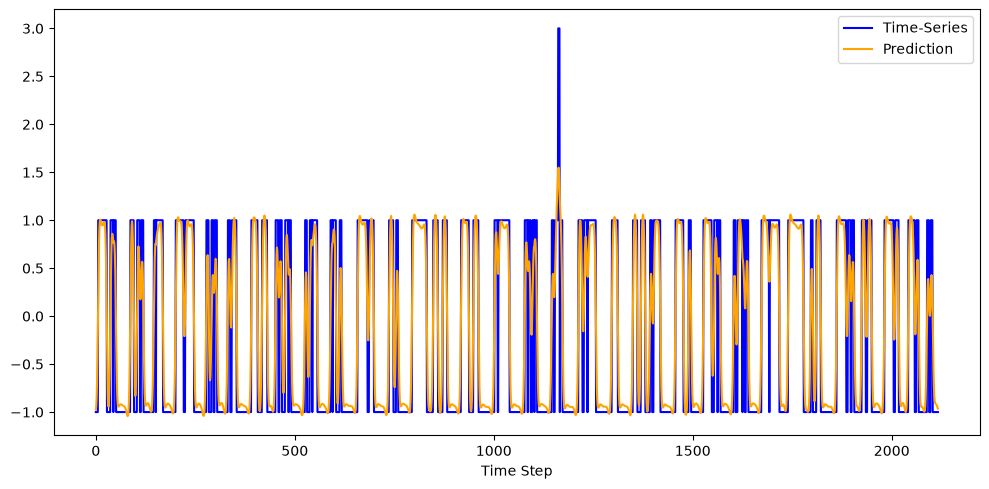

Channel T-5 Signal...
Epoch  25 | GG Loss: 0.089840 | GF Loss: -0.171998 | FC Loss: 0.683889 | DX Loss: 3.962824 | DZ Loss: 5.176221
Epoch  50 | GG Loss: 0.101611 | GF Loss: -0.609087 | FC Loss: 0.547666 | DX Loss: 0.747423 | DZ Loss: 2.777506
Epoch  75 | GG Loss: 0.126820 | GF Loss: -1.547872 | FC Loss: 0.368441 | DX Loss: -2.206702 | DZ Loss: 0.871085
Epoch 100 | GG Loss: 0.195245 | GF Loss: -3.298061 | FC Loss: 0.140141 | DX Loss: -3.614024 | DZ Loss: 0.014706
Epoch 125 | GG Loss: 0.378949 | GF Loss: -5.843444 | FC Loss: 0.011057 | DX Loss: -2.814728 | DZ Loss: -0.467390
Epoch 150 | GG Loss: 0.722894 | GF Loss: -7.880308 | FC Loss: 0.046238 | DX Loss: -1.160608 | DZ Loss: -1.386230
Epoch 175 | GG Loss: 1.255817 | GF Loss: -9.164466 | FC Loss: 0.075894 | DX Loss: 0.238529 | DZ Loss: -3.172391
Epoch 200 | GG Loss: 1.947152 | GF Loss: -9.663074 | FC Loss: 0.093212 | DX Loss: 1.311886 | DZ Loss: -5.866906
Epoch 225 | GG Loss: 2.386951 | GF Loss: -9.170609 | FC Loss: 0.091361 | DX Loss: 

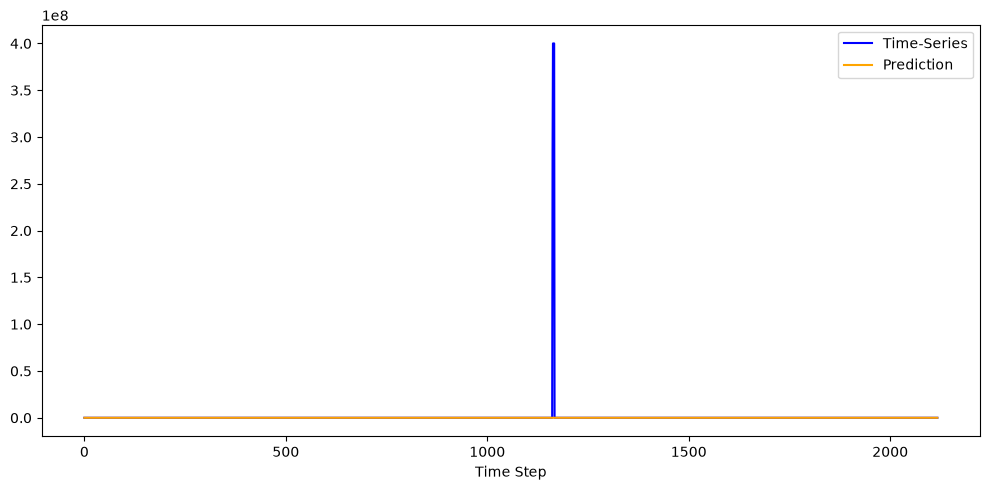

Channel T-8 Signal...
Epoch  25 | GG Loss: 0.079376 | GF Loss: -0.157547 | FC Loss: 0.904787 | DX Loss: 6.917043 | DZ Loss: 6.930606
Epoch  50 | GG Loss: 0.092208 | GF Loss: -0.195145 | FC Loss: 0.857719 | DX Loss: 5.708685 | DZ Loss: 6.188055
Epoch  75 | GG Loss: 0.105750 | GF Loss: -0.249131 | FC Loss: 0.809854 | DX Loss: 4.471937 | DZ Loss: 5.327164
Epoch 100 | GG Loss: 0.121024 | GF Loss: -0.321505 | FC Loss: 0.759742 | DX Loss: 3.259433 | DZ Loss: 4.380414
Epoch 125 | GG Loss: 0.139558 | GF Loss: -0.420597 | FC Loss: 0.705978 | DX Loss: 2.074457 | DZ Loss: 3.387807
Epoch 150 | GG Loss: 0.163348 | GF Loss: -0.553894 | FC Loss: 0.646781 | DX Loss: 0.980035 | DZ Loss: 2.407674
Epoch 175 | GG Loss: 0.194087 | GF Loss: -0.739572 | FC Loss: 0.580085 | DX Loss: -0.002682 | DZ Loss: 1.474637
Epoch 200 | GG Loss: 0.236807 | GF Loss: -0.990914 | FC Loss: 0.503947 | DX Loss: -0.924459 | DZ Loss: 0.645012
Epoch 225 | GG Loss: 0.296813 | GF Loss: -1.341258 | FC Loss: 0.416753 | DX Loss: -1.680

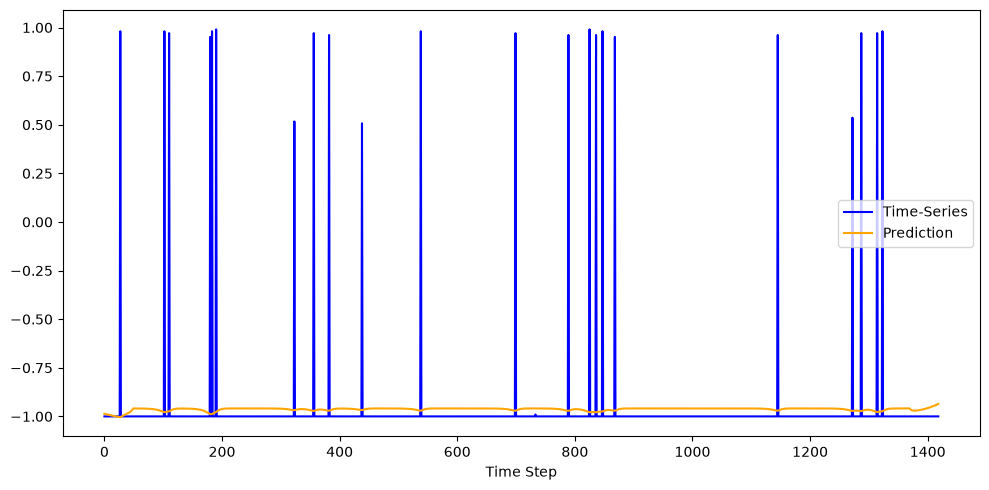

Channel T-9 Signal...
Epoch  25 | GG Loss: 0.068354 | GF Loss: 0.065215 | FC Loss: 0.066220 | DX Loss: 8.226266 | DZ Loss: 7.410439
Epoch  50 | GG Loss: 0.068245 | GF Loss: 0.067568 | FC Loss: 0.060466 | DX Loss: 7.760411 | DZ Loss: 7.118128
Epoch  75 | GG Loss: 0.068196 | GF Loss: 0.070038 | FC Loss: 0.055123 | DX Loss: 7.265935 | DZ Loss: 6.787554
Epoch 100 | GG Loss: 0.068232 | GF Loss: 0.072079 | FC Loss: 0.050160 | DX Loss: 6.753756 | DZ Loss: 6.437188
Epoch 125 | GG Loss: 0.068327 | GF Loss: 0.074264 | FC Loss: 0.045541 | DX Loss: 6.223451 | DZ Loss: 6.032240
Epoch 150 | GG Loss: 0.068416 | GF Loss: 0.075361 | FC Loss: 0.041251 | DX Loss: 5.681825 | DZ Loss: 5.638699
Epoch 175 | GG Loss: 0.068483 | GF Loss: 0.077272 | FC Loss: 0.037278 | DX Loss: 5.149763 | DZ Loss: 5.205016
Epoch 200 | GG Loss: 0.068554 | GF Loss: 0.078903 | FC Loss: 0.033612 | DX Loss: 4.622860 | DZ Loss: 4.756951
Epoch 225 | GG Loss: 0.068612 | GF Loss: 0.080374 | FC Loss: 0.030257 | DX Loss: 4.110938 | DZ Los

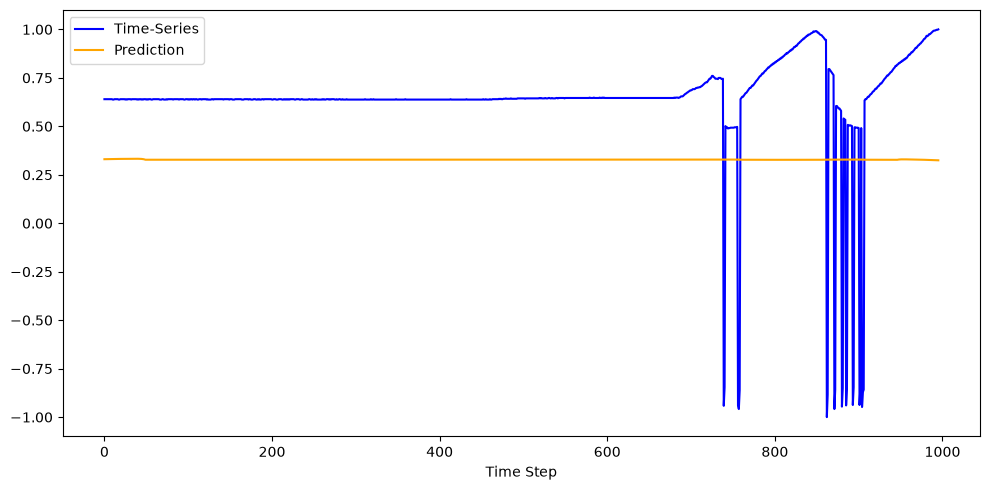

------------------
MSL Metrics
------------------
[point] Precision: 0.269 | Recall: 0.784 | F1: 0.366
[area] Precision: 0.266 | Recall: 0.815 | F1: 0.374


In [17]:
total_metrics = {name: np.zeros(3) for (name, _) in MSL_HYPERPARAMS["rec_error_funcs"]}
total_evaluated = 0

for msl_channel, X_train, X_test, y_test in zip(msl_channel_names, msl_train, msl_test, msl_test_y):
    # all data points are considered to be normal in the training tensor,
    # thus the labels consist of a tensor full of zeros
    y_train = torch.zeros(X_train.shape[0])

    print(f"Channel {msl_channel} Signal...")

    X_train = np.expand_dims(X_train[:, 0], axis=1)
    X_test = np.expand_dims(X_test[:, 0], axis=1)
    
    # try:
    metrics = run_pipeline(
        X=X_train, y=y_train,
        X_test=X_test, y_test=y_test,
        **MSL_HYPERPARAMS
    )
    for key in total_metrics:
        total_metrics[key] += np.array(metrics[key])
    total_evaluated += 1
    # except:
        # continue

print("------------------")
print("MSL Metrics")
print("------------------")

for key in total_metrics:
    total_metrics[key] = total_metrics[key] / total_evaluated
    print(f"[{key}] Precision: {total_metrics[key][0]:.3f} | Recall: {total_metrics[key][1]:.3f} | F1: {total_metrics[key][2]:.3f}")

### **SMAP**

In [12]:
SMAP_HYPERPARAMS = NASA_HYPERPARAMS.copy()
SMAP_HYPERPARAMS["verbose"] = False

In [13]:
smap_split_url = f"{NASA_SPLIT_REPO}{NASA_SMAP_SPLIT}"
smap_split = pd.read_csv(smap_split_url)

# extract the file names corresponding to the SMAP dataset
smap_channels_names = list(smap_split["chan_id"].values)
# add the .npy file extensions to the SMAP file names
smap_file_names = [f"{smap_file_name}.npy" for smap_file_name in smap_channels_names]
# sort them alphabetically
smap_file_names.sort()

In [14]:
smap_train: list[np.ndarray] = []
smap_test: list[np.ndarray] = []
smap_test_y: list[list] = []

for smap_file_name in smap_file_names:
    # load both the train and test time series for the same channel, concatenate
    # the time series and add them to the MSL dataset
    smap_train_ts = np.load(os.path.join(nasa_train_path, smap_file_name))
    smap_test_ts = np.load(os.path.join(nasa_test_path, smap_file_name))

    # extract the anomaly labels for the test time-series
    # -4 is needed to get rid of the file extension from the name
    row = nasa_labels[nasa_labels["chan_id"] == smap_file_name[:-4]]
    smap_test_interval_str = row["anomaly_sequences"].iloc[0]
    smap_test_interval = ast.literal_eval(smap_test_interval_str)
    smap_test_labels = intervals_to_points(smap_test_interval, len(smap_test_ts))

    smap_train.append(smap_train_ts)
    smap_test.append(smap_test_ts)

    smap_test_y.append(smap_test_labels)

In [16]:
total_metrics = {name: np.zeros(3) for (name, _) in SMAP_HYPERPARAMS["rec_error_funcs"]}
total_evaluated = 0

for smap_channel, X_train, X_test, y_test in zip(smap_channels_names, smap_train, smap_test, smap_test_y):
    # all data points are considered to be normal in the training tensor,
    # thus the labels consist of a tensor full of zeros
    y_train = torch.zeros(X_train.shape[0])

    print(f"Channel {smap_channel} Signal...")

    X_train = np.expand_dims(X_train[:, 0], axis=1)
    X_test = np.expand_dims(X_test[:, 0], axis=1)
    
    try:
        metrics = run_pipeline(
            X=X_train, y=y_train,
            X_test=X_test, y_test=y_test,
            **SMAP_HYPERPARAMS
        )
        for key in total_metrics:
            total_metrics[key] += np.array(metrics[key])
        total_evaluated += 1
    except:
        continue

print("------------------")
print("SMAP Metrics")
print("------------------")

for key in total_metrics:
    total_metrics[key] = total_metrics[key] / total_evaluated
    print(f"[{key}] Precision: {total_metrics[key][0]:.3f} | Recall: {total_metrics[key][1]:.3f} | F1: {total_metrics[key][2]:.3f}")

Channel A-1 Signal...
Channel A-2 Signal...
Channel A-3 Signal...
Channel A-4 Signal...
Channel A-5 Signal...
Channel A-6 Signal...
Channel A-7 Signal...
Channel A-8 Signal...
Channel A-9 Signal...
Channel B-1 Signal...


/time-series-ad-gan/src/utils/errors.py:199: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Z_dx = zscore(np.array(agg_dx))
/time-series-ad-gan/src/utils/errors.py:199: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Z_dx = zscore(np.array(agg_dx))


Channel D-1 Signal...
Channel D-11 Signal...
Channel D-12 Signal...


/time-series-ad-gan/src/utils/errors.py:199: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Z_dx = zscore(np.array(agg_dx))
/time-series-ad-gan/src/utils/errors.py:199: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Z_dx = zscore(np.array(agg_dx))


Channel D-13 Signal...


...

Channel G-3 Signal...
Channel G-4 Signal...
Channel G-6 Signal...
Channel G-7 Signal...
Channel P-1 Signal...
Channel P-3 Signal...
Channel P-4 Signal...


/time-series-ad-gan/src/utils/errors.py:199: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Z_dx = zscore(np.array(agg_dx))
/time-series-ad-gan/src/utils/errors.py:199: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Z_dx = zscore(np.array(agg_dx))


Channel P-7 Signal...
Channel R-1 Signal...


/time-series-ad-gan/src/utils/errors.py:199: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Z_dx = zscore(np.array(agg_dx))
/time-series-ad-gan/src/utils/errors.py:199: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  Z_dx = zscore(np.array(agg_dx))


Channel S-1 Signal...
Channel T-1 Signal...
Channel T-2 Signal...
Channel T-3 Signal...
------------------
SMAP Metrics
------------------
[point] Precision: 0.358 | Recall: 0.660 | F1: 0.406
[area] Precision: 0.261 | Recall: 0.805 | F1: 0.356
